In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from itertools import combinations

In [ ]:
f2 = '../data/OTS/'
outf = '../data/output/figures/'

In [3]:
all_seqs = pd.read_csv(f2 + 'OTS_all_studies_combined.csv.gz')
all_seqs = all_seqs.loc[all_seqs['Author'] != 'Garner et al.'] # these are MAIT cells

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/2120730268.py:1: DtypeWarning: Columns (10,25,33) have mixed types. Specify dtype option on import or set low_memory=False.
  all_seqs = pd.read_csv(f2 + 'OTS_all_studies_combined.csv.gz')


In [4]:
meta = all_seqs[['Run', 'Disease', 'CancerType', 'Species', 'Strain', 'TSource', 'TType', 'TSubtype', 'Treatment']].drop_duplicates()

In [5]:
meta['TSource'].value_counts()

pbmc                          1149
tumor                          297
csf                             55
metastatic_lymph_node           25
peripheral_blood                24
thoracic_duct                   24
tonsil                          24
balf                            21
lymph_node                      21
cervix                          20
bone_marrow                     20
skin                            18
unclear                         16
pooled_pbmc_tonsil_adenoid      16
skin_tumor                      16
thyroid                          9
adrenal_tumor                    9
adjacent_normal_tissue           8
pbmc_and_bal                     7
normal_kidney                    6
primary_focus                    5
lung_lymph_node                  4
spleen                           4
mesenteric_lymph_node            4
jejunum                          4
inguinal_lymph_node              4
lung                             4
liver_metastasis                 2
decidua             

In [6]:
tsource_simple = {
    'peripheral_blood':'PBMC',
    'pbmc':'PBMC',
    'skin_tumor':'tumor',
    'adrenal_tumor':'tumor',
    'primary_focus':'tumor',
    'lung_lymph_node' : 'lymph_node',
    'mesenteric_lymph_node' : 'lymph_node',
    'inguinal_lymph_node' : 'lymph_node',
    'liver_metastasis':'tumor',
    'peritonneal_metastasis':'tumor',
    'metastatic_lymph_node':'tumor',
    'adjacent_normal_tissue':'normal',
    'skin':'normal',
    'lung':'normal',
    'thoracic_duct':'normal',
    'thyroid':'normal',
    'tonsil':'normal',
    'balf':'normal',
    'normal_kidney':'normal',
    'jejunum':'normal',
    'cervix':'normal',
    'csf':'normal',
    'decidua':'normal',
    'pooled_pbmc_tonsil_adenoid':'PBMC_and_tissue',
    'pbmc_and_liver':'PBMC_and_tissue',
    'pbmc_and_bal':'PBMC_and_tissue',
}

In [7]:
meta['TSource-simplified'] = list(map(lambda x: tsource_simple.get(x, x), meta['TSource']))
meta['TSource-simplified'].value_counts()

PBMC               1173
tumor               355
normal              195
lymph_node           33
PBMC_and_tissue      23
bone_marrow          20
unclear              16
spleen                4
Name: TSource-simplified, dtype: int64

In [8]:
meta['TSubtype'].value_counts()

none                                      794
includes_naive                            384
memory_enriched                           224
tetramer_sorted                           101
antigen_stimulated                         29
memory                                     27
cd45ro+                                    26
cd45ra-_cd154+_cd69+                       22
cd154+                                     22
tetramer_qvd                               20
cd45ra-_cd137+_cd69+                       20
KRAS-9mer_tetramer+                        20
pd1+                                       18
cd95+                                      16
unstimulated                               13
tetramer_ksa                               13
hiv-specific_memory_+_b_cells_spike_in     12
KRAS-10mer_tetramer+                       12
20_hrs_stimulation                         10
10_days_stimulation                         5
hiv-specific_memory                         4
cmv-specific_memory_+_b_cells_spik

In [9]:
tsubtype_simple = {
    'tetramer_sorted':'tetramer_sorted',
    'KRAS-9mer_tetramer+':'tetramer_sorted',
    'KRAS-10mer_tetramer+':'tetramer_sorted',
    'tetramer_ksa':'tetramer_sorted',
    'tetramer_qvd':'tetramer_sorted',
    'hiv-specific_memory_+_b_cells_spike_in':'viral_memory',
    'cmv-specific_memory_+_b_cells_spike_in':'viral_memory',
    'hiv-specific_memory':'viral_memory',
    'cmv-specific_memory':'viral_memory',
    'memory_enriched':'memory',
    '20_hrs_stimulation':'antigen_stimulated',
    '10_days_stimulation':'antigen_stimulated',
    'naive':'includes_naive',
    'cd45ra-_cd154+_cd69+':'AIM+',
    'cd45ra-_cd137+_cd69+':'AIM+',
    'cd154+':'AIM+',
    'pd1+':'AIM+',
    'treg_cells':'unstimulated',
    'tfr_cells':'unstimulated',
    'tfh_cells':'unstimulated',
    'cd25hitfh_cells':'AIM+',
    'cd95+':'AIM+',
    'cd45ro+':'memory'
}

In [10]:
meta['TSubtype-simplified'] = list(map(lambda x: tsubtype_simple.get(x, x), meta['TSubtype']))
meta['TSubtype-simplified'].value_counts()

none                  794
includes_naive        387
memory                277
tetramer_sorted       166
AIM+                  102
antigen_stimulated     44
unstimulated           25
viral_memory           24
Name: TSubtype-simplified, dtype: int64

In [11]:
meta['TType'].unique()

array(['unsorted', 'cd8+', 'cd4+', 'live', 'cd3+', 'cd45+'], dtype=object)

In [12]:
meta['Treatment'].unique()

array(['adoptive_cell_therapy', 'untreated', 'ipinivo', 'nivoexposed',
       'thymalfasin', 'ribociclib_and_anti-pd1', 'rna_neoantigen_vaccine',
       'covid_vaccine', 'pd1_blockade'], dtype=object)

In [13]:
estimatedMI = pd.read_csv('../data/output/mutual_info/OTS/estimated_mutual_info_all_runs.csv')
estimatedMI.columns = ['name', 'real', 'shuffle']
estimatedMI[['Run', 'vars']] = estimatedMI['name'].str.split(pat = '_', n = 1, expand=True)
estimatedMI[['var1','var2']] = estimatedMI['vars'].str.split(pat = '-', n = 1, expand=True)
estimatedMI = estimatedMI.drop(['name','vars'], axis=1)
estimatedMI['real_MI'] = estimatedMI['real'] - estimatedMI['shuffle']
estimatedMI['var1'] = estimatedMI['var1'].replace('cdr3a','CDR3a')
estimatedMI['var2'] = estimatedMI['var2'].replace('cdr3a','CDR3a')
estimatedMI['var1'] = estimatedMI['var1'].replace('cdr3b','CDR3b')
estimatedMI['var2'] = estimatedMI['var2'].replace('cdr3b','CDR3b')

In [14]:
estimatedMI

,real,shuffle,Run,var1,var2,real_MI
0,19.203368,12.702725,SRR10039337,Ja,CDR3a,6.500643
1,13.967036,12.703157,SRR10039337,Ja,CDR3b,1.263879
2,1.388986,1.216513,SRR10039337,Ja,Jb,0.172473
3,6.607404,5.192769,SRR10039337,Jb,CDR3a,1.414636
4,10.927125,5.326162,SRR10039337,Jb,CDR3b,5.600963
...,...,...,...,...,...,...
26290,7.367087,6.839325,SRR8890815,Vb,CDR3a,0.527762
26291,8.420887,6.891021,SRR8890815,Vb,CDR3b,1.529866
26292,1.635080,1.559514,SRR8890815,Vb,Ja,0.075567
26293,0.631767,0.616591,SRR8890815,Vb,Jb,0.015176


In [15]:
estimatedMI = pd.merge(meta, estimatedMI)

In [16]:
var_pairs = [
    ("CDR3a", "CDR3b"),
    ("Va", "Vb"),
    ("Ja", "Jb")
]

In [18]:
estimatedMI['SourceSubtype'] = estimatedMI['TSource-simplified'] + '-' + estimatedMI['TSubtype-simplified']
estimatedMI['SourceSubtype'] = pd.Categorical(estimatedMI['SourceSubtype'],
                                              categories = ['bone_marrow-none', 'lymph_node-none', 'spleen-none', 'unclear-none',
                                                            'normal-none', 'normal-unstimulated', 'normal-memory', 'normal-AIM+',
                                                            'PBMC-none', 'PBMC-unstimulated', 'PBMC-includes_naive', 'PBMC-memory',  'PBMC-antigen_stimulated', 'PBMC-AIM+','PBMC-tetramer_sorted',
                                                            'PBMC_and_tissue-none', 'PBMC_and_tissue-AIM+',
                                                            'tumor-none', 'tumor-AIM+','tumor-tetramer_sorted',
                                                            ],
                                              ordered=True)

In [19]:
estimatedMI['TypeSubtype'] = estimatedMI['TType'] + '-' + estimatedMI['TSubtype-simplified']
estimatedMI['TypeSubtype'] = pd.Categorical(estimatedMI['TypeSubtype'],
                                            categories = ['live-none', 'cd45+-none', 
                                                        'cd3+-none', 'cd3+-antigen_stimulated', 'cd3+-AIM+',
                                                        'cd4+-none', 'cd4+-unstimulated', 'cd4+-includes_naive', 'cd4+-memory', 'cd4+-antigen_stimulated', 'cd4+-AIM+',
                                                        'cd8+-none', 'cd8+-memory', 'cd8+-antigen_stimulated', 'cd8+-AIM+', 'cd8+-tetramer_sorted',
                                                        'unsorted-none', 'unsorted-unstimulated', 'unsorted-includes_naive', 'unsorted-memory', 'unsorted-antigen_stimulated'
                                                        ],
                                            ordered=True)

In [20]:
estimatedMI['TypeSubtype'].unique().tolist()

['unsorted-none',
 'cd4+-AIM+',
 'cd8+-AIM+',
 'unsorted-memory',
 'unsorted-includes_naive',
 'live-none',
 'cd3+-AIM+',
 'cd8+-memory',
 'cd3+-none',
 'cd8+-none',
 'cd8+-tetramer_sorted',
 'cd4+-memory',
 'cd4+-includes_naive',
 'cd3+-antigen_stimulated',
 'cd45+-none',
 'cd4+-unstimulated',
 'cd4+-antigen_stimulated',
 'cd4+-none',
 'unsorted-antigen_stimulated']

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/2183741561.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


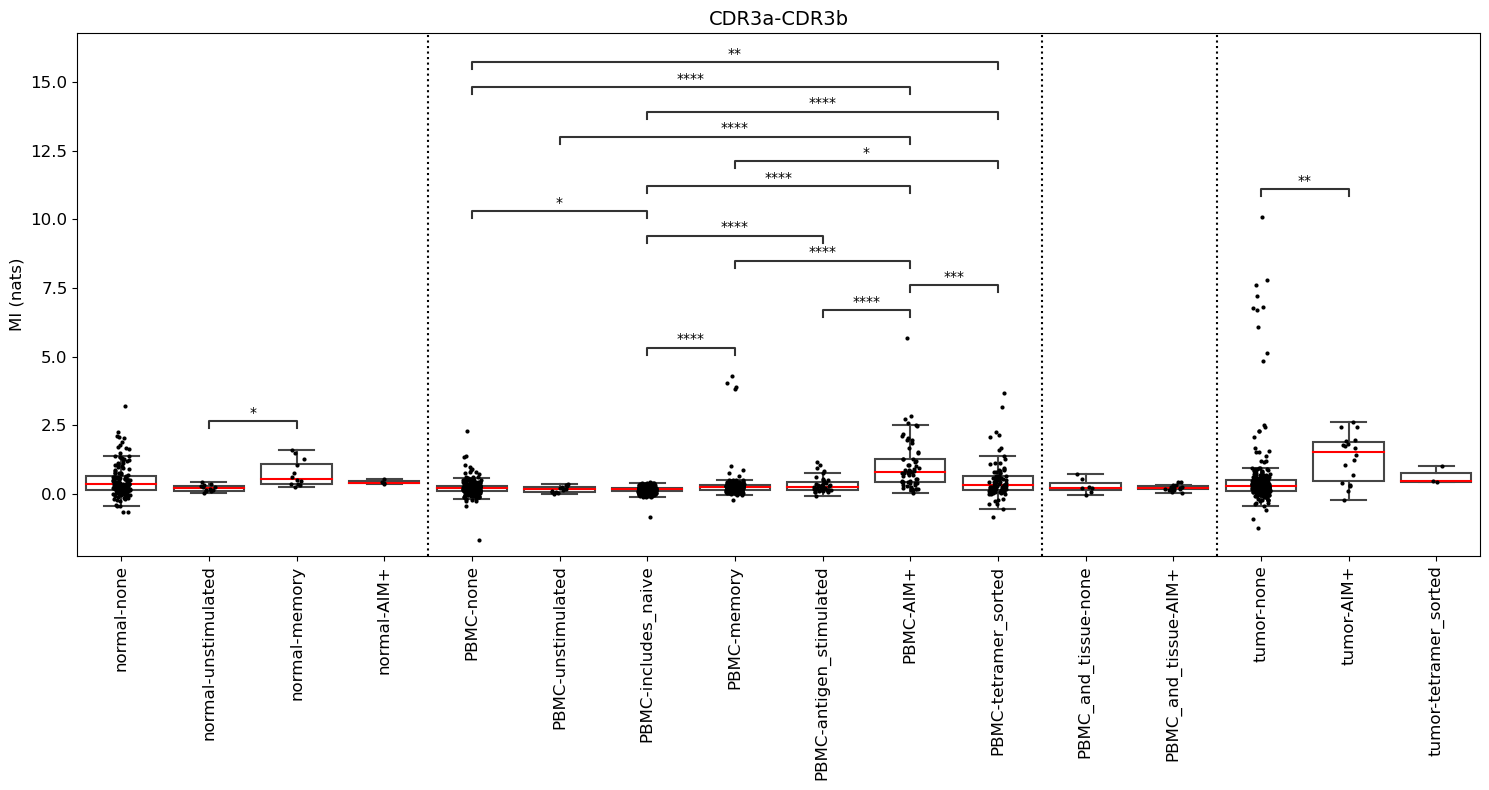

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/2183741561.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


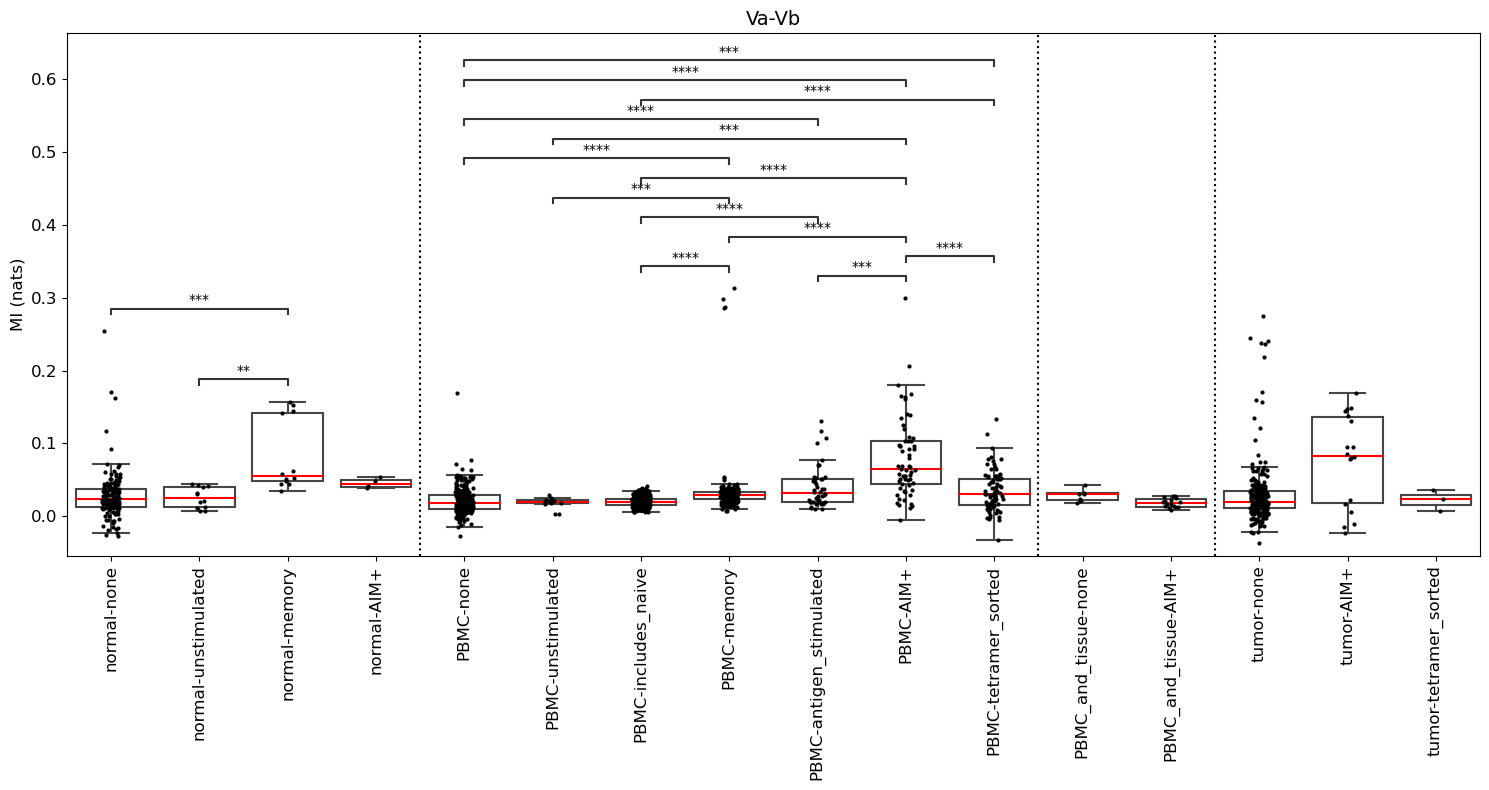

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/2183741561.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


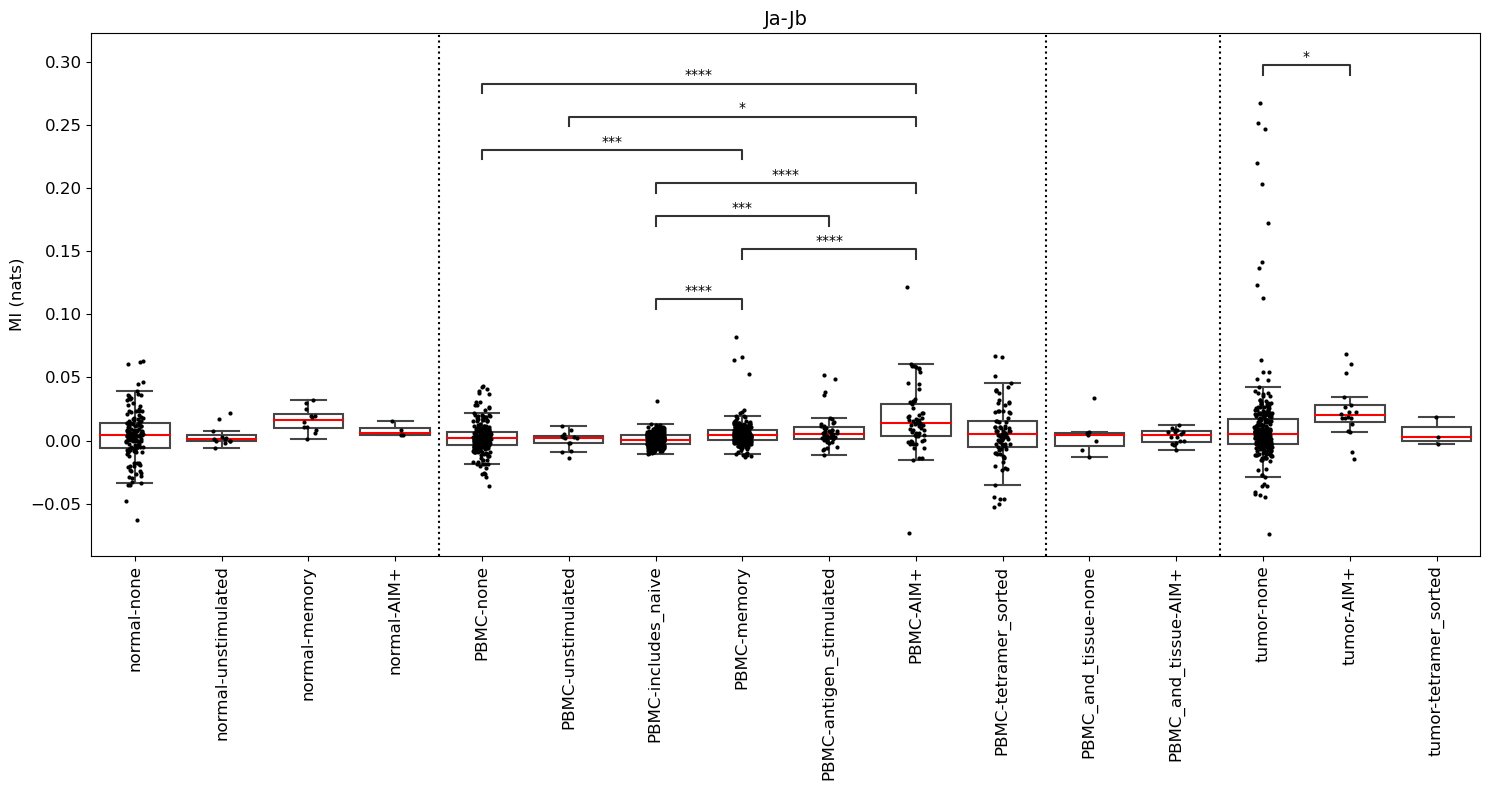

In [21]:
vars = estimatedMI[['var1','var2']].drop_duplicates()

for j, (var1, var2) in enumerate(var_pairs):

    X = estimatedMI.loc[(estimatedMI['var1'] == var1) & (estimatedMI['var2'] == var2)].copy()
    # X = X.loc[X['TSubtype-simplified'] != 'none']

    repeated_source = X[['TSource-simplified', 'TSubtype-simplified']].drop_duplicates()['TSource-simplified'].value_counts().loc[X[['TSource-simplified', 'TSubtype-simplified']].drop_duplicates()['TSource-simplified'].value_counts() > 1].index
    X = X.loc[X['TSource-simplified'].isin(repeated_source)]

    order = X['SourceSubtype'].cat.categories.tolist()
    sources = sorted(X['TSource-simplified'].unique().tolist())
    subtypes = sorted(X['TSubtype-simplified'].unique().tolist())

    _pairs = [(x,y) for x, y in combinations(subtypes, 2)]
    pairs = [(s + '-' + x, s + '-' + y) for x, y in _pairs for s in sources]
    pairs = [(x,y) for (x,y) in pairs if (x in X['SourceSubtype'].unique()) & (y in X['SourceSubtype'].unique())]

    order = [x for x in order if x in X['SourceSubtype'].unique()]

    f, ax = plt.subplots(figsize = (15,8), nrows = 1)

    sns.stripplot(X, y = 'real_MI', x = 'SourceSubtype', c = 'k',
                        order=order, size = 3, ax=ax)
    sns.boxplot(X, y = 'real_MI', x = 'SourceSubtype',
                order=order, showfliers = False, boxprops=dict(facecolor='None'), medianprops={"color": "red"}, ax=ax)

    annotator = Annotator(ax, pairs, data = X, y = 'real_MI', x = 'SourceSubtype', order=order)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', 
                        comparisons_correction='Bonferroni', hide_non_significant = True, verbose=0)
    annotator.apply_and_annotate()

    ax.axvline(3.5, ls=':', c = 'k')
    ax.axvline(10.5, ls=':', c = 'k')
    ax.axvline(12.5, ls=':', c = 'k')
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('MI (nats)', fontsize = 12)
    ax.set_title(var1 + '-' + var2, fontsize = 14)
    plt.tight_layout()
    plt.savefig(outf + 'OTS_MI_analysis_SourceSubtype_' + '-'.join([var1, var2]) + '.pdf', bbox_inches = 'tight')
    plt.show()

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/1336306814.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(X, y = 'real_MI', x = 'TypeSubtype', order=order,
/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/1336306814.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


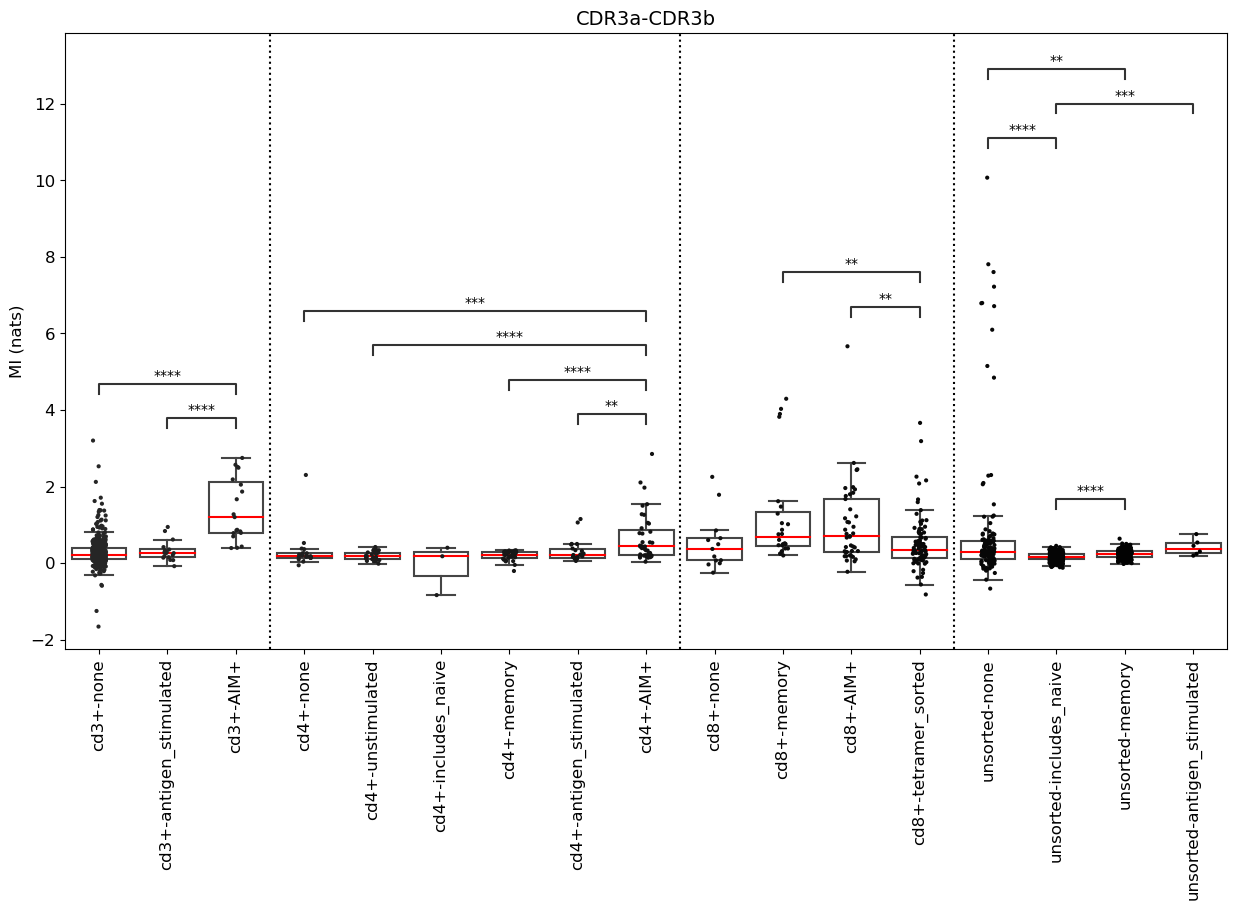

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/1336306814.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(X, y = 'real_MI', x = 'TypeSubtype', order=order,
/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/1336306814.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


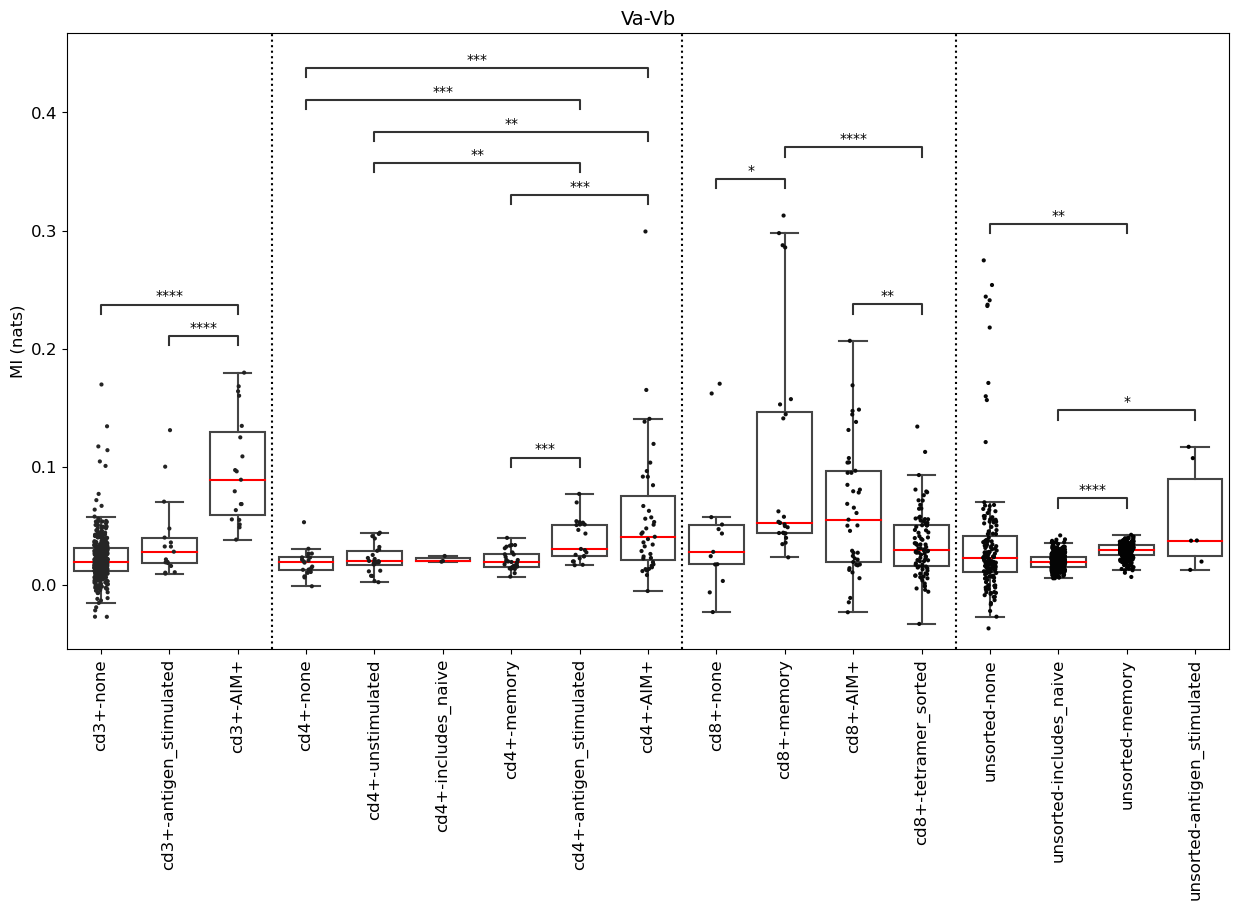

/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/1336306814.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(X, y = 'real_MI', x = 'TypeSubtype', order=order,
/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_89622/1336306814.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


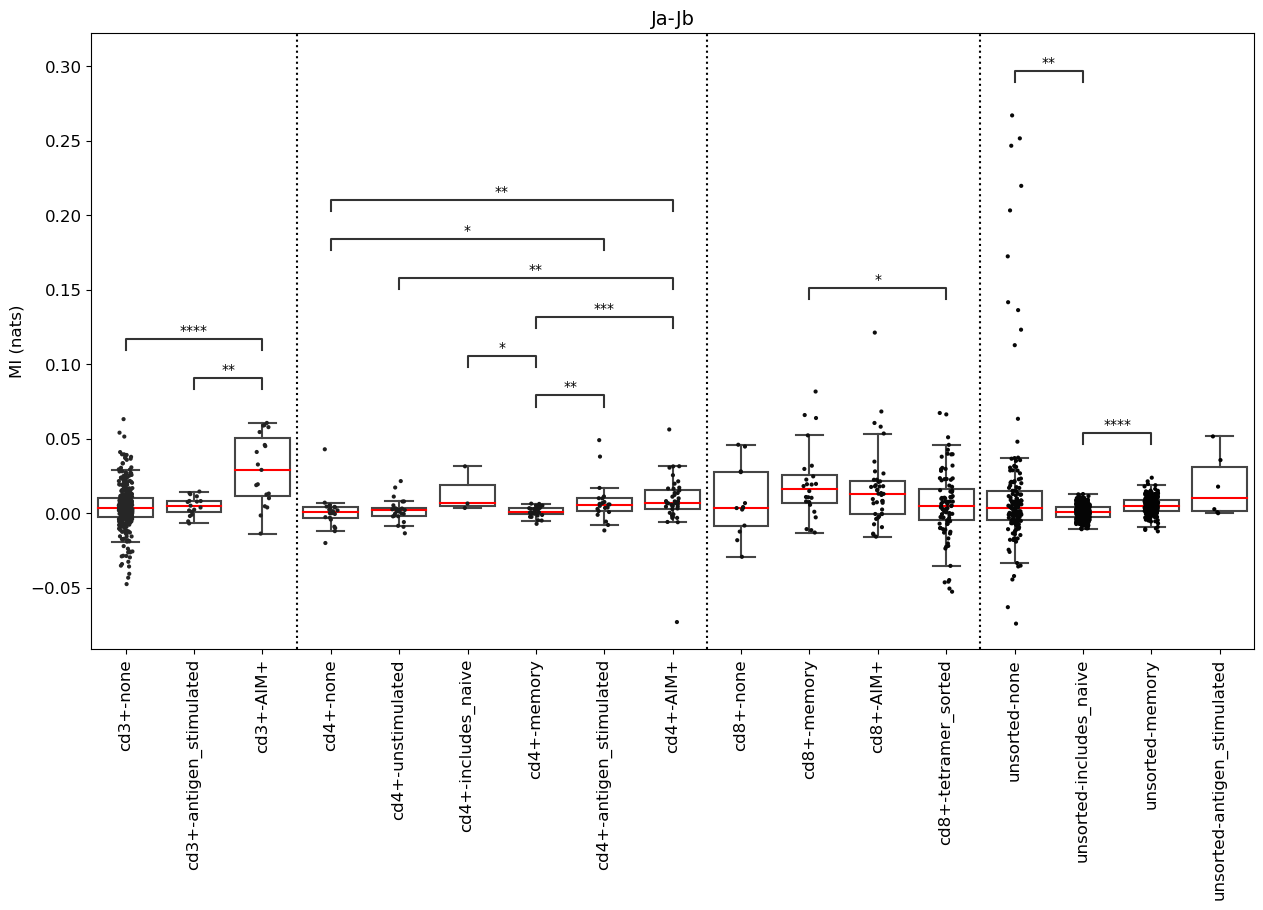

In [22]:
for i, (var1, var2) in enumerate(var_pairs):

    X = estimatedMI.loc[(estimatedMI['var1'] == var1) & (estimatedMI['var2'] == var2)].copy()

    repeated_types = X[['TType', 'TSubtype-simplified']].drop_duplicates()['TType'].value_counts().loc[X[['TType', 'TSubtype-simplified']].drop_duplicates()['TType'].value_counts() > 1].index
    X = X.loc[X['TType'].isin(repeated_types)]

    order = X['TypeSubtype'].cat.categories.tolist()
    sources = sorted(X['TType'].unique().tolist())
    subtypes = sorted(X['TSubtype-simplified'].unique().tolist())

    _pairs = [(x,y) for x, y in combinations(subtypes, 2)]
    pairs = [(s + '-' + x, s + '-' + y) for x, y in _pairs for s in sources]
    pairs = [(x,y) for (x,y) in pairs if (x in X['TypeSubtype'].unique()) & (y in X['TypeSubtype'].unique())]
    
    order = [x for x in order if x in X['TypeSubtype'].unique()]

    f, ax = plt.subplots(figsize = (15,8), nrows = 1)
    sns.stripplot(X, y = 'real_MI', x = 'TypeSubtype', order=order, 
                    palette = 'dark:k', size = 3, ax=ax)
    sns.boxplot(X, y = 'real_MI', x = 'TypeSubtype', order=order, 
                showfliers = False, boxprops=dict(facecolor='None'), medianprops={"color": "red"},)
    annotator = Annotator(ax, pairs, data = X, y = 'real_MI', x = 'TypeSubtype', order=order)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', 
                        comparisons_correction='BH', hide_non_significant = True, verbose=0)
    annotator.apply_and_annotate()

    ax.axvline(2.5, ls=':', c = 'k')
    ax.axvline(8.5, ls=':', c = 'k')
    ax.axvline(12.5, ls=':', c = 'k')
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('MI (nats)', fontsize = 12)
    ax.set_title(var1 + '-' + var2, fontsize = 14)
    plt.savefig(outf + 'OTS_MI_analysis_TypeSubtype_' + '-'.join([var1, var2]) + '.pdf', bbox_inches = 'tight')
    plt.show()